# The MLP Function Family and Activation Functions

A short mathematical tour of multilayer perceptrons, their universal
approximation property, and the two most common hidden-layer activations:
**ReLU** and **sigmoid**.

---

## 1. The Multilayer Perceptron (MLP)

An MLP is a composition of **affine maps** and **nonlinear activations**.
Given an input vector $\mathbf{x} \in \mathbb{R}^{d_0}$, an MLP with $L$
hidden layers is defined recursively by

$$
\mathbf{h}^{(0)} = \mathbf{x}
$$

$$
\mathbf{z}^{(l)} = \mathbf{W}_l \, \mathbf{h}^{(l-1)} + \mathbf{b}_l,
\qquad l = 1, \dots, L
$$

$$
\mathbf{h}^{(l)} = \phi\!\left( \mathbf{z}^{(l)} \right),
\qquad l = 1, \dots, L
$$

$$
\hat{\mathbf{y}} = \mathbf{W}_{L+1} \, \mathbf{h}^{(L)} + \mathbf{b}_{L+1}
$$

where:

- $\mathbf{W}_l \in \mathbb{R}^{d_l \times d_{l-1}}$ is the weight matrix of layer $l$,
- $\mathbf{b}_l \in \mathbb{R}^{d_l}$ is the bias vector,
- $\mathbf{z}^{(l)}$ is the **pre-activation** (logit),
- $\mathbf{h}^{(l)}$ is the **activation** (post-activation),
- $\phi : \mathbb{R} \to \mathbb{R}$ is a **nonlinear activation function** applied element-wise,
- the output layer is typically **linear** for regression, or **softmax** for classification.

The full parameter set is

$$
\Theta = \bigl\{ \mathbf{W}_l, \mathbf{b}_l \bigr\}_{l=1}^{L+1}
$$

---

## 2. The Function Family

Write the MLP as a single parametric map:

$$
f_\Theta : \mathbb{R}^{d_0} \to \mathbb{R}^{d_{L+1}}
$$

$$
f_\Theta(\mathbf{x})
= \mathbf{W}_{L+1} \,
\phi\!\Bigl( \mathbf{W}_L \,
\phi\bigl( \cdots \phi(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) \cdots \bigr)
+ \mathbf{b}_L \Bigr)
+ \mathbf{b}_{L+1}
$$

The family of functions reachable as $\Theta$ varies is

$$
\mathcal{F} = \bigl\{ f_\Theta \;:\; \Theta \in \mathbb{R}^{P} \bigr\}
$$

where $P = \sum_{l=1}^{L+1} (d_l d_{l-1} + d_l)$ is the total number of parameters.

### Why the nonlinearity matters

If $\phi$ were the identity, the network would collapse to a single
affine map:

$$
f_\Theta(\mathbf{x}) = \mathbf{W}_{\text{eff}} \, \mathbf{x} + \mathbf{b}_{\text{eff}}
$$

so depth would add **zero** expressivity. The activation $\phi$ is what
turns the MLP into a rich, non-linear function approximator.

### Universal approximation

Under mild conditions on $\phi$ (bounded, non-constant, continuous), the
MLP family is **dense** in the space of continuous functions on compact
sets. For every $g \in C(K)$ with $K \subset \mathbb{R}^{d_0}$ compact and
every $\varepsilon > 0$, there exists an MLP $f_\Theta$ such that

$$
\sup_{\mathbf{x} \in K} \bigl| f_\Theta(\mathbf{x}) - g(\mathbf{x}) \bigr| < \varepsilon
$$

This is the **Universal Approximation Theorem** (Cybenko 1989, Hornik 1991).
Depth and width trade off — deeper nets often need exponentially fewer
parameters to reach the same approximation error.

---

## 3. Activation: Sigmoid

The sigmoid (logistic) function maps $\mathbb{R}$ to $(0, 1)$:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### Properties

- **Range:** $(0, 1)$
- **Monotone increasing**, smooth ($C^\infty$)
- **Symmetric about $(0, \tfrac{1}{2})$:** $\sigma(-z) = 1 - \sigma(z)$
- **Derivative:**
  $$
  \sigma'(z) = \sigma(z) \bigl( 1 - \sigma(z) \bigr)
  $$
- **Maximum derivative:** $\max_z \sigma'(z) = \tfrac{1}{4}$ at $z = 0$
- **Saturating:** $\sigma(z) \to 0$ as $z \to -\infty$, $\sigma(z) \to 1$ as $z \to +\infty$

### Vanishing gradients

Because $\sigma'(z) \le 1/4$, gradients shrink multiplicatively through
depth. For a stack of $k$ sigmoid layers,

$$
\left| \frac{\partial \mathbf{h}^{(l)}}{\partial \mathbf{h}^{(l-k)}} \right|
\le \left( \tfrac{1}{4} \right)^{k}
$$

so gradients at early layers vanish exponentially with depth. This is the
classic **vanishing gradient problem**.

### Not zero-centered

Hidden activations have mean $1/2$, not $0$. This shifts the input to the
next layer and slows learning — one reason deep sigmoid nets train poorly.

### Where sigmoid still shines

- **Binary classification output** (probabilities in $(0, 1)$).
- **Gates inside LSTMs / GRUs** (forget, input, output gates).
- **Small shallow networks** where depth is not an issue.

---

## 4. Activation: ReLU

The Rectified Linear Unit is the simplest nonlinearity in wide use:

$$
\mathrm{ReLU}(z) = \max(0, z) =
\begin{cases}
z & z > 0 \\
0 & z \le 0
\end{cases}
$$

### Properties

- **Range:** $[0, \infty)$
- **Piecewise linear, non-smooth at $z = 0$**
- **Derivative (sub-gradient):**
  $$
  \mathrm{ReLU}'(z) =
  \begin{cases}
  1 & z > 0 \\
  0 & z < 0
  \end{cases}
  $$
  At $z = 0$ the derivative is conventionally set to $0$.
- **Non-saturating for $z > 0$:** derivative is exactly $1$, so gradients pass through unchanged
- **Sparse activations:** roughly half the units are zero for zero-mean inputs

### Why ReLU works so well

1. **No vanishing gradient** on the positive side: the Jacobian is an
   identity in the active region.
2. **Cheap to compute** (a single comparison).
3. **Sparse, efficient representations** that accelerate training.
4. **Scale invariance:** $\mathrm{ReLU}(cz) = c \cdot \mathrm{ReLU}(z)$ for $c > 0$.

### Initialization: He / Kaiming

To keep activation variance stable across layers, weights are drawn as

$$
\mathbf{W}_l \sim \mathcal{N}\!\left( 0, \; \frac{2}{d_{l-1}} \right)
$$

The factor $2$ accounts for the fact that roughly half of ReLU units are
active on average.

### The dying-ReLU problem

If a unit's pre-activation is always negative, its gradient is always $0$
and the unit never recovers. Remedies include:

- **Leaky ReLU:** $\mathrm{LeakyReLU}(z) = \max(\alpha z, z)$ with $\alpha \approx 0.01$
- **ELU / SELU:** smooth, negative-side variants
- **GELU / SiLU:** smooth, non-monotone variants used in transformers

---

## 5. Sigmoid vs. ReLU — Side by Side

| Property | Sigmoid $\sigma(z)$ | ReLU $\max(0, z)$ |
|---|---|---|
| Range | $(0, 1)$ | $[0, \infty)$ |
| Derivative | $\sigma(z)(1 - \sigma(z))$ | $\mathbb{1}[z > 0]$ |
| Max derivative | $1/4$ | $1$ |
| Saturates? | Yes (both sides) | No (positive side) |
| Zero-centered output? | No | No (but sparse) |
| Vanishing gradients | Severe with depth | Not on active units |
| Typical init | Xavier: $\mathcal{N}(0, 1/d_{l-1})$ | He: $\mathcal{N}(0, 2/d_{l-1})$ |
| Compute cost | $\exp$ | max |
| Common use | Outputs (binary), gates | Hidden layers |

### Numerical example — gradient through 5 layers

Assume every layer has $\sigma'(z) \approx 0.25$ for sigmoid and
$\mathrm{ReLU}'(z) = 1$ for ReLU. The backpropagated gradient ratio from
layer 5 to layer 1 is roughly:

- **Sigmoid:** $(0.25)^5 \approx 9.8 \times 10^{-4}$ — essentially zero
- **ReLU:** $1^5 = 1$ — untouched

That is why deep nets almost universally use ReLU-family activations for
their hidden layers.

---

## 6. Full Backpropagation Summary (for one hidden layer)

Consider a two-layer MLP with a single hidden layer and a scalar output:

$$
\mathbf{z} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1, \qquad
\mathbf{h} = \phi(\mathbf{z}), \qquad
\hat{y} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2
$$

Loss (MSE) on a mini-batch of size $m$:

$$
J = \frac{1}{m} \sum_{i=1}^{m} ( \hat{y}_i - y_i )^{2}
$$

### Gradients

$$
\frac{\partial J}{\partial \hat{y}} = \frac{2}{m} \bigl( \hat{y} - y \bigr)
$$

$$
\frac{\partial J}{\partial \mathbf{W}_2} = \frac{\partial J}{\partial \hat{y}} \, \mathbf{h}^{\top},
\qquad
\frac{\partial J}{\partial \mathbf{b}_2} = \sum_i \frac{\partial J}{\partial \hat{y}_i}
$$

$$
\frac{\partial J}{\partial \mathbf{h}} = \mathbf{W}_2^{\top} \frac{\partial J}{\partial \hat{y}}
$$

$$
\frac{\partial J}{\partial \mathbf{z}} =
\frac{\partial J}{\partial \mathbf{h}} \odot \phi'(\mathbf{z})
$$

$$
\frac{\partial J}{\partial \mathbf{W}_1} = \frac{\partial J}{\partial \mathbf{z}} \, \mathbf{x}^{\top},
\qquad
\frac{\partial J}{\partial \mathbf{b}_1} = \sum_i \frac{\partial J}{\partial \mathbf{z}_i}
$$

where $\odot$ denotes element-wise multiplication.

### The activation's role

The only place the choice of $\phi$ enters backprop is the term
$\phi'(\mathbf{z})$:

- **Sigmoid:** $\phi'(\mathbf{z}) = \mathbf{h} \odot (\mathbf{1} - \mathbf{h})$
- **ReLU:** $\phi'(\mathbf{z}) = \mathbb{1}[\mathbf{z} > 0]$

Everything else in the chain rule is identical.

---

## 7. Choosing an Activation — Practical Guide

| Scenario | Recommended activation |
|---|---|
| Hidden layers of a deep feedforward / CNN | ReLU (or Leaky ReLU, GELU) |
| Hidden layers of a very shallow net | Sigmoid or Tanh |
| Binary classification output | Sigmoid |
| Multiclass classification output | Softmax |
| Regression output | Linear (no activation) |
| Recurrent nets (LSTM / GRU gates) | Sigmoid + Tanh |
| Transformer feed-forward | GELU or SwiGLU |

The rule of thumb:

$$
\text{Deep net} \Rightarrow \text{ReLU-family} \qquad
\text{Shallow net or output} \Rightarrow \text{sigmoid / linear}
$$

---

## 8. Summary

- An **MLP** is a composition of affine maps and element-wise nonlinearities.
  Its parameterized family is dense in the space of continuous functions.
- The **sigmoid** $\sigma(z) = (1 + e^{-z})^{-1}$ is smooth, bounded in
  $(0, 1)$, with derivative $\sigma(1 - \sigma) \le 1/4$. It saturates and
  causes vanishing gradients in deep stacks, but remains the natural choice
  for binary outputs and recurrent gates.
- **ReLU** $\max(0, z)$ is cheap, non-saturating for $z > 0$, and yields
  sparse activations. It is the default hidden-layer activation in modern
  deep learning.
- The forward pass differs only in $\phi(\cdot)$; the backward pass differs
  only in the term $\phi'(\mathbf{z})$. Everything else in backprop is
  identical.

$$
\boxed{\; \text{MLP} = \text{affine} \circ \phi \circ \text{affine} \circ \phi \circ \cdots \circ \text{affine} \;}
$$

Training Batch GD (sigmoid)...
Training SGD (sigmoid)...
Training Mini-Batch GD (sigmoid)...

  Batch GD      final MSE = 0.05360
  SGD           final MSE = 0.06855
  Mini-batch GD final MSE = 0.04418


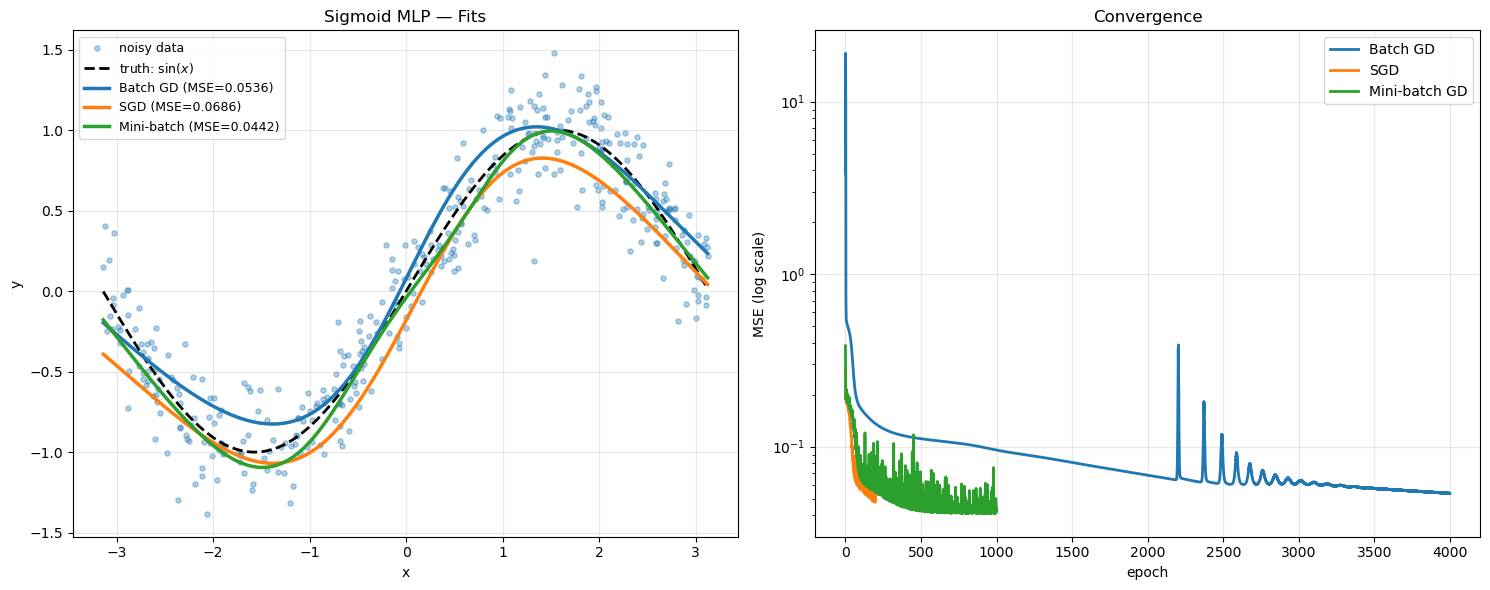

In [4]:
# =============================================================================
# MLP REGRESSION WITH SIGMOID HIDDEN ACTIVATION — TUNED VERSION
# Fits  y = sin(x) + noise  on  x in [-pi, pi]
# Compares Batch GD, SGD, Mini-Batch GD
# =============================================================================
#
# Key tricks to make sigmoid work well:
#   - Xavier init:      W ~ N(0, 1/fan_in)
#   - Small LR:         0.05 (batch), 0.005 (SGD), 0.02 (mini-batch)
#   - Many epochs:      sigmoid is slow, so 4000-8000 epochs
#   - Wider first layer: sigmoid has low per-unit expressivity
#   - Linear output:    target y in [-1, 1], not (0, 1)
#   - No gradient clipping needed with a proper LR
#
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# -----------------------------------------------------------------------------
# Data
# -----------------------------------------------------------------------------
def generate_data(N=400, sigma=0.20, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-np.pi, np.pi, size=N)
    y = np.sin(X) + rng.normal(0, sigma, size=N)
    return X, y


def standardize(x):
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd, mu, sd


# -----------------------------------------------------------------------------
# Sigmoid MLP (hidden = sigmoid, output = linear)
# -----------------------------------------------------------------------------
def sigmoid(z):
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


class SigmoidMLP:
    def __init__(self, layer_sizes, seed=0):
        rng = np.random.default_rng(seed)
        self.W, self.b = [], []
        for i in range(len(layer_sizes) - 1):
            fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
            scale = np.sqrt(1.0 / fan_in)     # Xavier for sigmoid
            self.W.append(rng.normal(0, scale, size=(fan_out, fan_in)))
            self.b.append(np.zeros(fan_out))

    def forward(self, X):
        cache = {"A": [X], "Z": []}
        A = X
        for i in range(len(self.W) - 1):
            Z = A @ self.W[i].T + self.b[i]
            A = sigmoid(Z)
            cache["Z"].append(Z)
            cache["A"].append(A)
        Z_out = A @ self.W[-1].T + self.b[-1]   # linear output
        cache["Z"].append(Z_out)
        cache["A"].append(Z_out)
        return Z_out, cache

    def backward(self, cache, y):
        m = y.shape[0]
        A = cache["A"]
        n_layers = len(self.W)
        dZ = (2.0 / m) * (A[-1] - y.reshape(-1, 1))
        dW = [None] * n_layers
        db = [None] * n_layers
        for i in reversed(range(n_layers)):
            dW[i] = dZ.T @ A[i]
            db[i] = dZ.sum(axis=0)
            if i > 0:
                dA = dZ @ self.W[i]
                h = A[i]                     # <-- activation of layer i (not i-1)
                dZ = dA * h * (1.0 - h)      # sigmoid derivative
        return dW, db

    def step(self, dW, db, lr):
        for i in range(len(self.W)):
            self.W[i] -= lr * dW[i]
            self.b[i] -= lr * db[i]


# -----------------------------------------------------------------------------
# Trainers
# -----------------------------------------------------------------------------
def train_batch_gd(X, y, hidden=(64, 32), lr=0.2, epochs=4000, seed=0):
    X_col, y_col = X.reshape(-1, 1), y.reshape(-1, 1)
    net = SigmoidMLP([1, *hidden, 1], seed=seed)
    losses = []
    for _ in range(epochs):
        _, cache = net.forward(X_col)
        dW, db = net.backward(cache, y_col)
        net.step(dW, db, lr)
        y_hat, _ = net.forward(X_col)
        losses.append(float(np.mean((y_hat - y_col) ** 2)))
    return net, losses


def train_sgd(X, y, hidden=(64, 32), lr=0.005, epochs=200, seed=0):
    X_col, y_col = X.reshape(-1, 1), y.reshape(-1, 1)
    net = SigmoidMLP([1, *hidden, 1], seed=seed)
    losses = []
    N = X_col.shape[0]
    rng = np.random.default_rng(seed + 1)
    for _ in range(epochs):
        for i in rng.permutation(N):
            Xi, yi = X_col[i:i+1], y_col[i:i+1]
            _, cache = net.forward(Xi)
            dW, db = net.backward(cache, yi)
            net.step(dW, db, lr)
        y_hat, _ = net.forward(X_col)
        losses.append(float(np.mean((y_hat - y_col) ** 2)))
    return net, losses


def train_minibatch_gd(X, y, hidden=(64, 32), lr=0.05,
                       epochs=1000, batch_size=16, seed=0):
    X_col, y_col = X.reshape(-1, 1), y.reshape(-1, 1)
    net = SigmoidMLP([1, *hidden, 1], seed=seed)
    losses = []
    N = X_col.shape[0]
    rng = np.random.default_rng(seed + 1)
    for _ in range(epochs):
        idx = rng.permutation(N)
        for s in range(0, N, batch_size):
            b = idx[s:s + batch_size]
            Xb, yb = X_col[b], y_col[b]
            _, cache = net.forward(Xb)
            dW, db = net.backward(cache, yb)
            net.step(dW, db, lr)
        y_hat, _ = net.forward(X_col)
        losses.append(float(np.mean((y_hat - y_col) ** 2)))
    return net, losses


# -----------------------------------------------------------------------------
# Run
# -----------------------------------------------------------------------------
X, y = generate_data(N=400, sigma=0.20, seed=0)
X_std, mu, sd = standardize(X)

print("Training Batch GD (sigmoid)...")
net_bgd, losses_bgd = train_batch_gd(
    X_std, y, hidden=(64, 32), lr=0.2, epochs=4000, seed=0
)

print("Training SGD (sigmoid)...")
net_sgd, losses_sgd = train_sgd(
    X_std, y, hidden=(64, 32), lr=0.005, epochs=200, seed=0
)

print("Training Mini-Batch GD (sigmoid)...")
net_mbgd, losses_mbgd = train_minibatch_gd(
    X_std, y, hidden=(64, 32), lr=0.05, epochs=1000, batch_size=16, seed=0
)

print()
print(f"  Batch GD      final MSE = {losses_bgd[-1]:.5f}")
print(f"  SGD           final MSE = {losses_sgd[-1]:.5f}")
print(f"  Mini-batch GD final MSE = {losses_mbgd[-1]:.5f}")


# -----------------------------------------------------------------------------
# Predict + plot
# -----------------------------------------------------------------------------
x_grid = np.linspace(X.min(), X.max(), 500)
x_grid_std = (x_grid - mu) / sd
Xs_true = np.sin(x_grid)


def predict(net, xg):
    yh, _ = net.forward(xg.reshape(-1, 1))
    return yh.ravel()


y_bgd = predict(net_bgd, x_grid_std)
y_sgd = predict(net_sgd, x_grid_std)
y_mbgd = predict(net_mbgd, x_grid_std)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(X, y, s=14, alpha=0.35, label="noisy data")
ax.plot(x_grid, Xs_true, "k--", lw=2, label=r"truth: $\sin(x)$")
ax.plot(x_grid, y_bgd,  lw=2.5, label=f"Batch GD (MSE={losses_bgd[-1]:.4f})")
ax.plot(x_grid, y_sgd,  lw=2.5, label=f"SGD (MSE={losses_sgd[-1]:.4f})")
ax.plot(x_grid, y_mbgd, lw=2.5, label=f"Mini-batch (MSE={losses_mbgd[-1]:.4f})")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Sigmoid MLP — Fits")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(losses_bgd,  lw=2, label="Batch GD")
ax.plot(losses_sgd,  lw=2, label="SGD")
ax.plot(losses_mbgd, lw=2, label="Mini-batch GD")
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log scale)")
ax.set_title("Convergence")
ax.legend()

plt.tight_layout()
plt.savefig("mlp_sigmoid_regression.png", dpi=130)
plt.show()